# Week 10 - Introduction to Neural Networks: Part II

**Student Name 1, Student Name 2**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with stochastic gradient descent and the role of the learning rate and batch size
>* ways to cope with overfitting, including early stopping, regularization, and dropout
>* incorporating the keras model into an sklearn pipeline

It may be helpful to have last week's notebook open to recall how to build, compile, and fit neural networks in keras.

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

First, we need to install the versions of tensorflow and keras needed for this workshop. The versions in Notable's Machine Learning and Language notebook are older, so anyone using Noteable, should start a Python 3 notebook and then uncomment the lines below to install the correct versions.

In [ ]:
#!pip install tensorflow==2.20.0
#!pip install tf-keras==2.20.1


## Packages

Let's load the some of the packages needed for this workshop. 

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Part 1: Motorcycle Data

In the first part of this workshop, we will work with the motorcyle data, which giving a series of measurements of head acceleration in a simulated motorcycle accident, used to test crash helmets.

This is a small data set with only 1 feature (time) and 1 numerical outcome (head acceleration) recorded at $N=133$ time points, but we will use it illustrate the role of some of parameters in neural networks and gradient descent.


In [2]:
# Load motorcycle data
mcycle = pd.read_csv('mcycle.csv', index_col=0)
N = mcycle.shape[0]
D = mcycle.shape[1]-1
y = mcycle['accel']
X = mcycle.drop('accel', axis=1)
print('Number of observations: ', N)

# Scale the inputs
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X = ss.fit_transform(X)

# Set seed for reproducibility
keras.utils.set_random_seed(11205)

Number of observations:  133


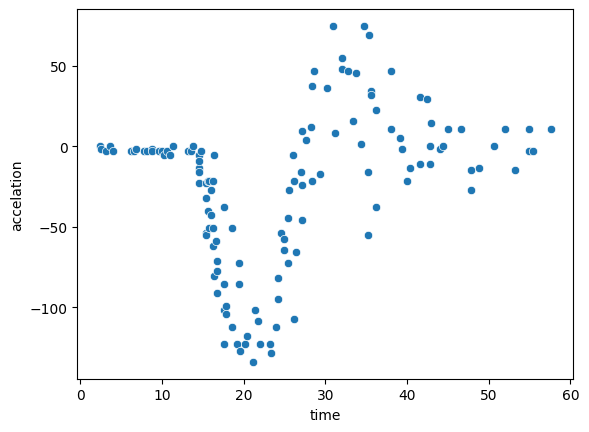

In [3]:
# Plot the data
sns.scatterplot(mcycle, x = 'times', y = 'accel')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 1 (CORE)

Define a neural network in keras with two hidden layers, the first with 20 hidden units and the second with 10 hiddent units, and ReLU activations. You should call your model `model_reg`.

How many parameters does the model have? 

**Note:** since this is a regression task, the final activation should be the identity (`linear` function in keras).

In [4]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)

In [5]:
model_reg = keras.models.Model(input_layer, output_layer)
model_reg.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

The model has 261 parameters.

### Compile the model

Now, let's compile the model. Here, we are using
- the mean squared error loss
- the SGD optimizer
- computing additional metrics, namely R2 and MAE.

In [6]:
model_reg.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

Before, we fit the data, we will first shuffle it. Note the data here is stored in order of time. If we did not first shuffle, the validation would look very different (and consist of the final time points).

In [7]:
from sklearn.utils import shuffle
X, y = shuffle(X, y, random_state=11205)

### 🚩 Exercise 2 (CORE)

Fit the model with the following options:
- 300 epochs
- batch size equal to $N$ (hint: set the optional parameter `batch_size` in `.fit()`)
- validation set to 10% of the data
- you may also want to set `verbose=0` to avoid printing the output

Plot the metrics as functions of the number of epochs. Comment on their behavior and if you think the model should be trained for more or less epochs.

In [8]:
model_reg.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=N)

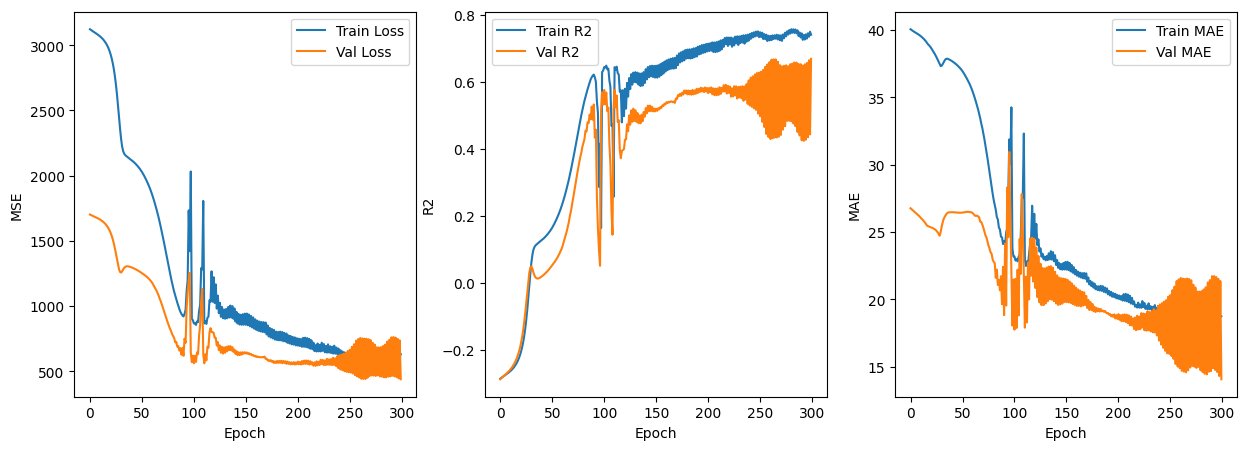

In [9]:
# Plot the training history
history = model_reg.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

Initially there is a rapid improvement, but as the epochs progress the behavior becomes unstable. Due this instability, particularly for latter epochs, more training does not seem to be needed. We could train for less, e.g. around 200 epochs seems to be enough for the curves to plateau.

Let's plot the predictions of the fitted model.

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


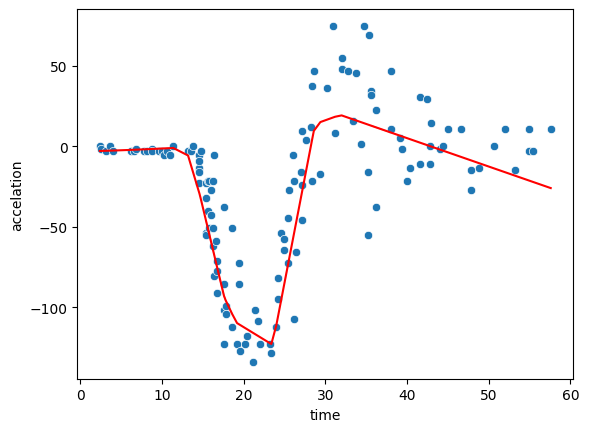

In [10]:
# Compute predictions
yhat = model_reg.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 3 (CORE): Exploring the role of the learning rate

Repeat the above but change the learning rate to 

a) `learning_rate=1e-2` and call this `model_reg2`

b) `learning_rate=1e-4` and call this `model_reg3`

What is the effect of the learning rate?
- Comment on the behavior of the metrics as a function epochs for these choices compared with the previous. 
- Plot also the predictions and comment on they compare with the previous model fit.

*Note:* redefine the model before compiling so that the biases and weights are re-initialized randomly.

In [11]:
# Option a: larger learning rate

# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg2 = keras.models.Model(input_layer, output_layer)

model_reg2.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-2),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

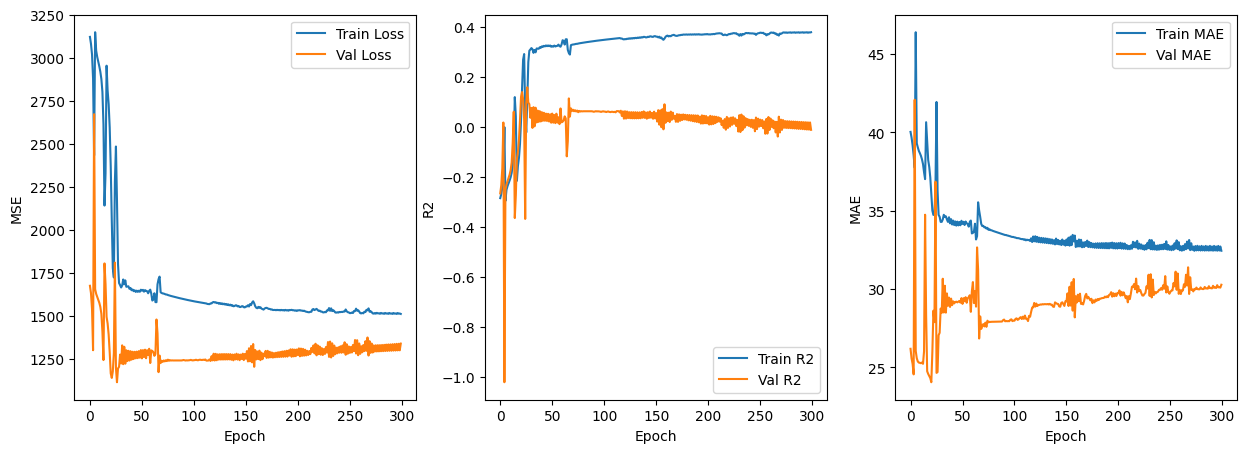

In [12]:
# Fit the model
model_reg2.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=N)

# Plot the training history
history = model_reg2.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


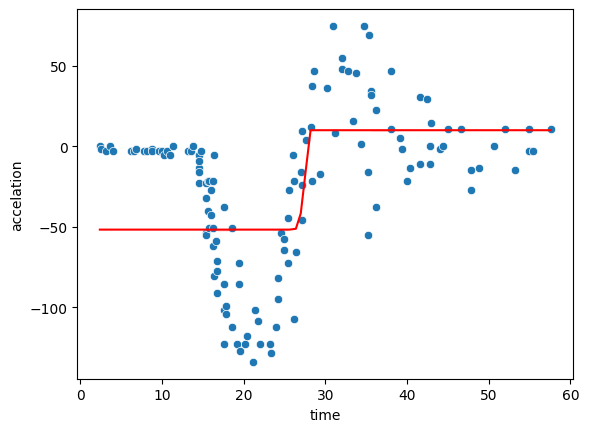

In [13]:
# Compute predictions
yhat = model_reg2.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

In [14]:
# Option b: smaller learning rate

# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg3 = keras.models.Model(input_layer, output_layer)

model_reg3.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-4),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

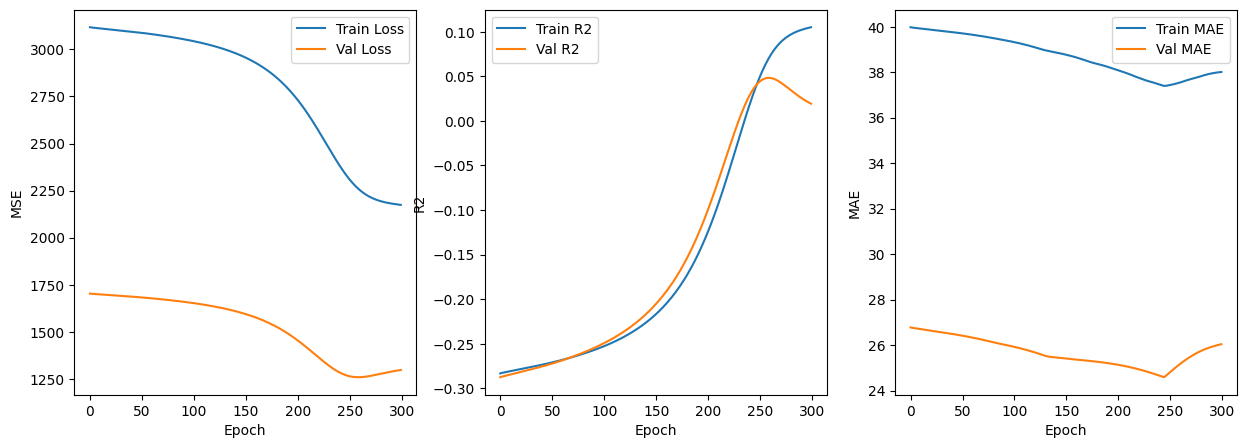

In [15]:
# Fit the model
model_reg3.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=N)

# Plot the training history
history = model_reg3.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x304435bc0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


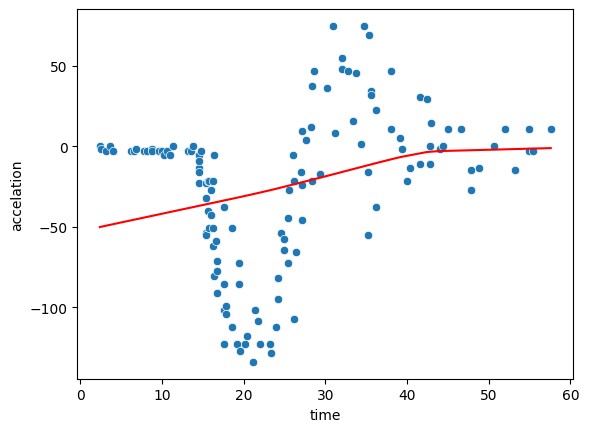

In [16]:
# Compute predictions
yhat = model_reg3.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

The learning rate has a huge effect. 

- When it is set too large, gradient descent becomes quite volatile and is unable to converge to a good local minimum. The predicted regression function is quite poor.
- When it is set too small, gradient descent converges very slowly and the 300 epochs is not enough. And with only 300 epochs, the predicted regression function is quite poor. Below we retrain for 4*300=1200 more epochs (so 1500 in total), and the results are much better but of course at the cost of higher run time. This is only a small dataset, so the increased training time is not too bad, but for larger data, the additional training time could be infeasible. 

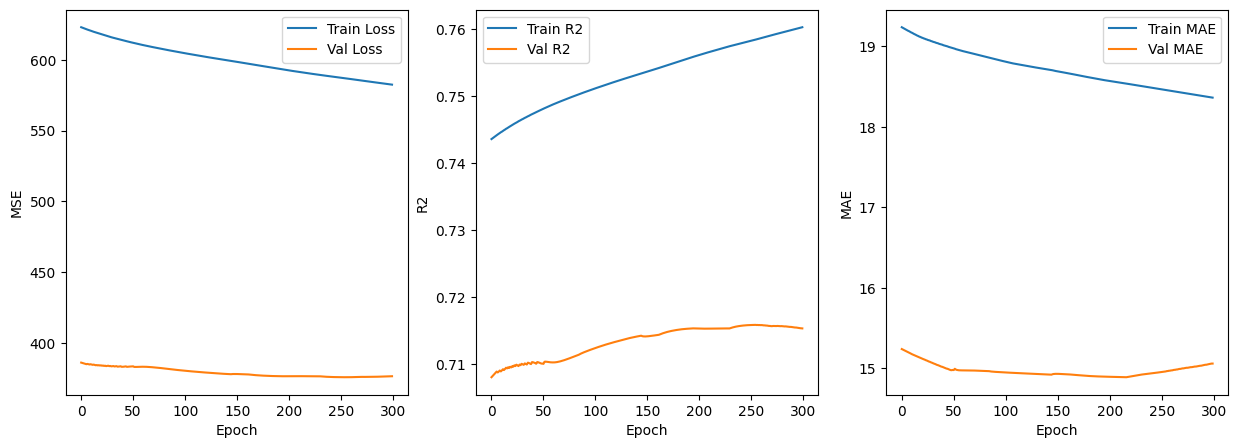

In [20]:
# Fit the model
model_reg3.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=N)

# Plot the training history
history = model_reg3.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


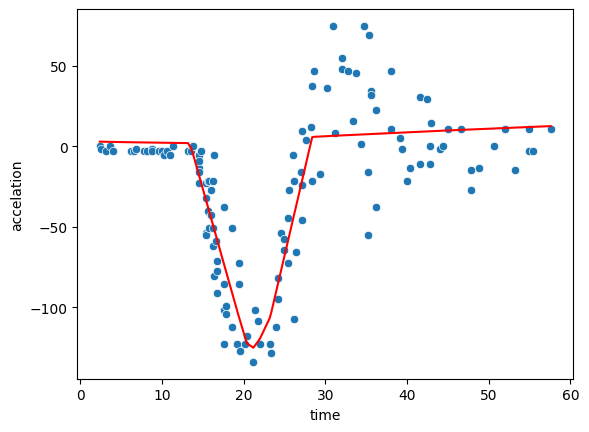

In [21]:
# Compute predictions
yhat = model_reg3.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

### 🚩 Exercise 4 (CORE): Exploring the effect of the batch size

Previously we used gradient descent (`batch_size=N`). Consider changing the batch size to:

a) `batch_size=20` and call this `model_reg4`

b) `batch_size=1` and call this `model_reg5`

Comment on the effect of the batch size, and your preferred choice.

*Note:* redefine the model before compiling so that the biases and weights are re-initialized randomly.

In [22]:
# Option a: batch size of 20

# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg4 = keras.models.Model(input_layer, output_layer)

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

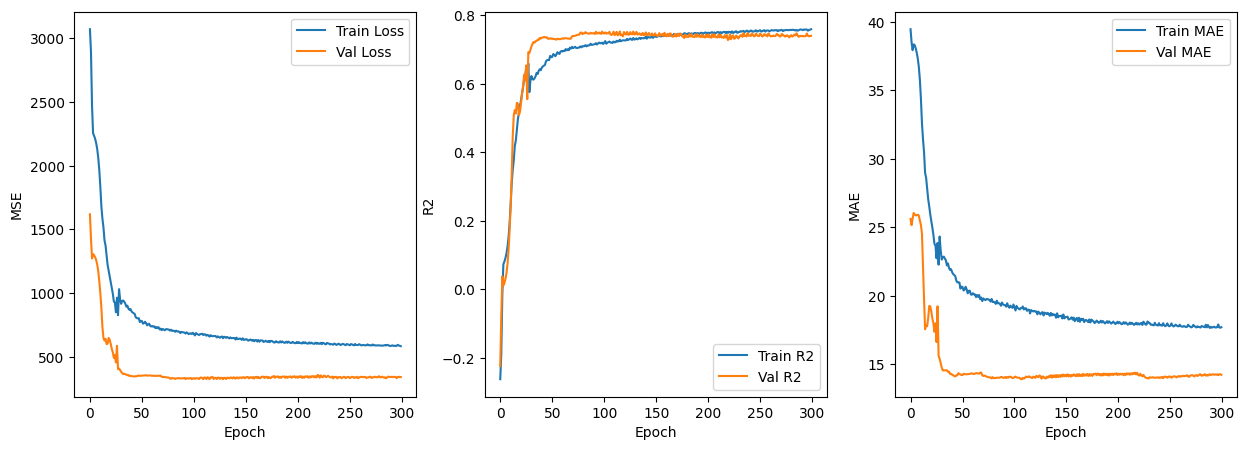

In [23]:
# Fit the model
model_reg4.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20)

# Plot the training history
history = model_reg4.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


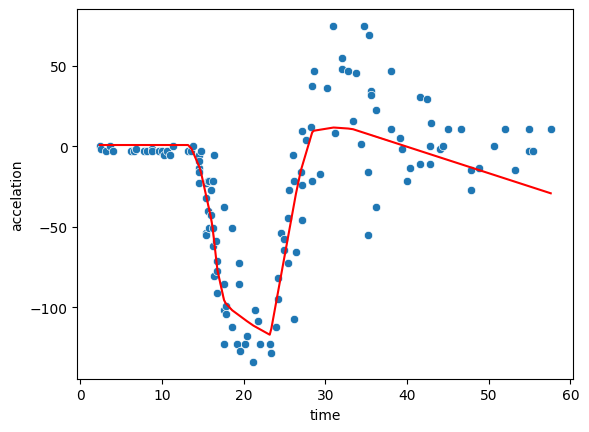

In [24]:
# Compute predictions
yhat = model_reg4.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

In [25]:
# Option b: batch size of 1

# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg5 = keras.models.Model(input_layer, output_layer)

model_reg5.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

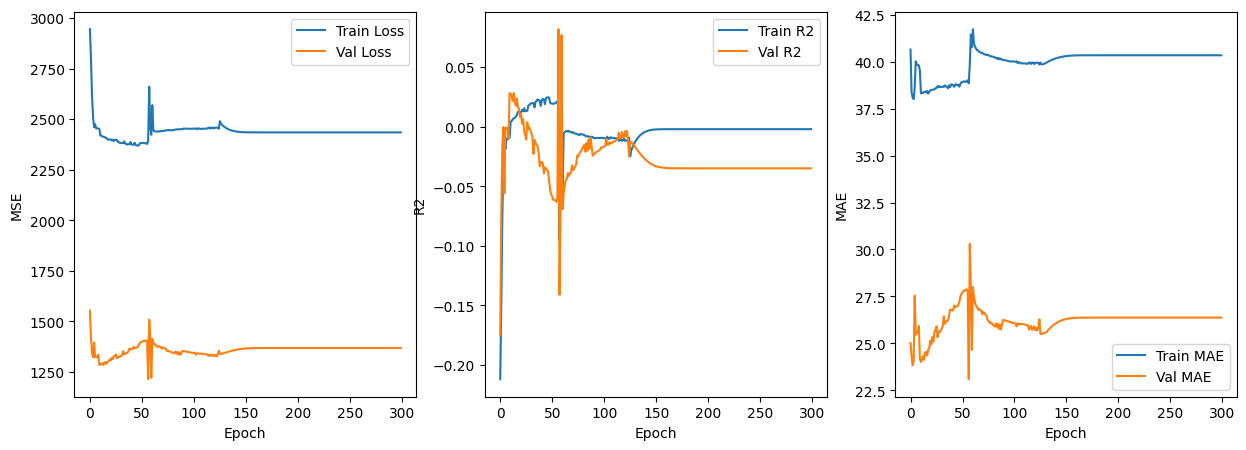

In [26]:
# Fit the model
model_reg5.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=1)

# Plot the training history
history = model_reg5.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


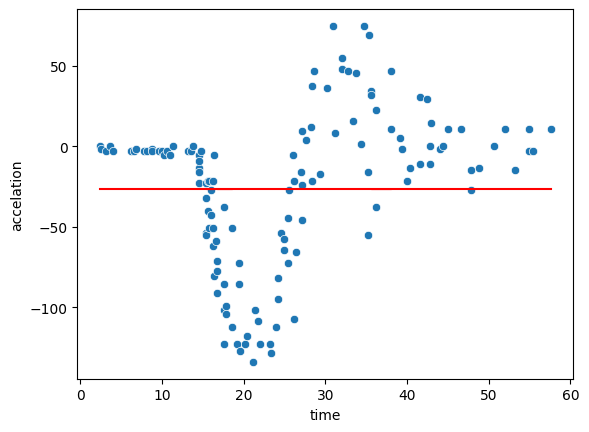

In [27]:
# Compute predictions
yhat = model_reg5.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

Compared to gradient descent, stochastic gradient descent greatly helps to speed up convergence. In gradient descent, only one update is performed at each epoch, as the gradients are computed and averaged across all data points. Instead with stochastic gradient descent, we only need the gradients across the minibatch before making the step and we can take many steps for each epoch, allowing faster convergence. 

In this case, the batch size of 20 provides quite fast convergence, while with the batch size of 1, the gradient estimates are too noisy and it is not able to converge to a good solution. The batch size of 20  also allows reduced total run time (compared to the batch size of 1) by enabling fast matrix computations within batch, instead of looping over more batches with smaller batch size. 

### Early stopping

When using minibatches, SGD converges much faster and 300 epochs seems unnecessary. We can use keras's [EarlyStopping](https://keras.io/api/callbacks/early_stopping/) to exit early. In this case, we need to decide:
- the metric to monitor (`monitor`)
- the minimum change in the monitored quantity to qualify as an improvement (`min_delta`)
- the number of epochs with no improvement after which training will be stopped (`patience`)

In the following, we use early stopping to avoid training for the full 300 epochs.

In [28]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg4 = keras.models.Model(input_layer, output_layer)

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

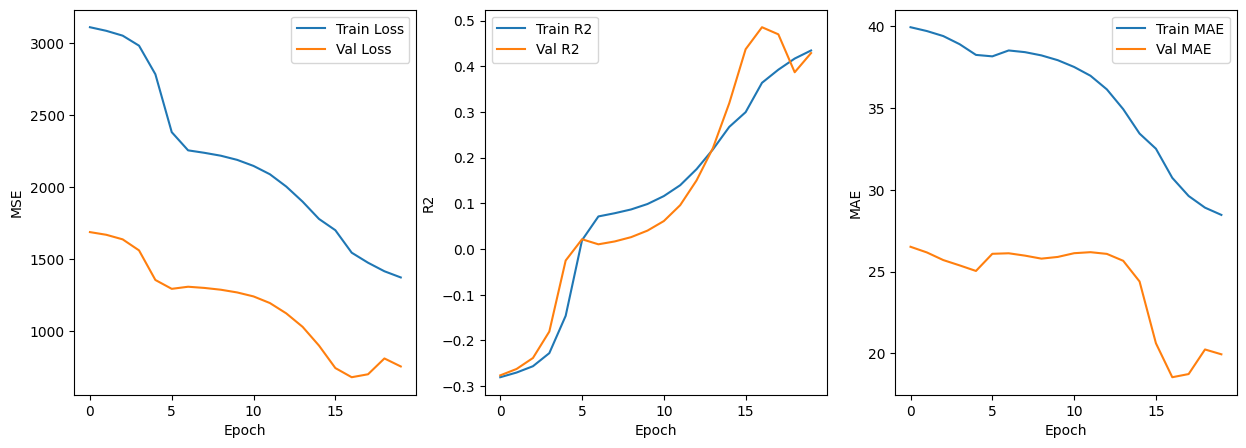

In [29]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta = 0, mode = 'min', 
                                         patience=3, restore_best_weights=True)

model_reg4.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20, callbacks=[callback])

# Plot the training history
history = model_reg4.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


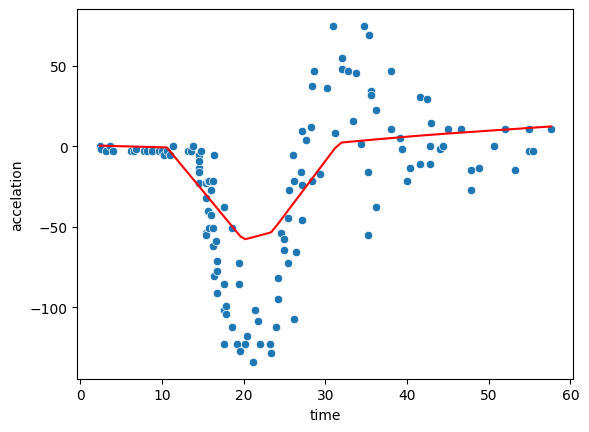

In [30]:
# Compute predictions
yhat = model_reg4.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

But, it seems that it has stopped too early!

### 🚩 Exercise 5 (CORE)

Try changing any or all of the three parameters determining the early stopping criteria. What have you decided and why? How has it changed the number of epochs before exiting?

In [31]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer2)
model_reg4 = keras.models.Model(input_layer, output_layer)

model_reg4.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer= keras.optimizers.SGD(learning_rate=1e-3),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

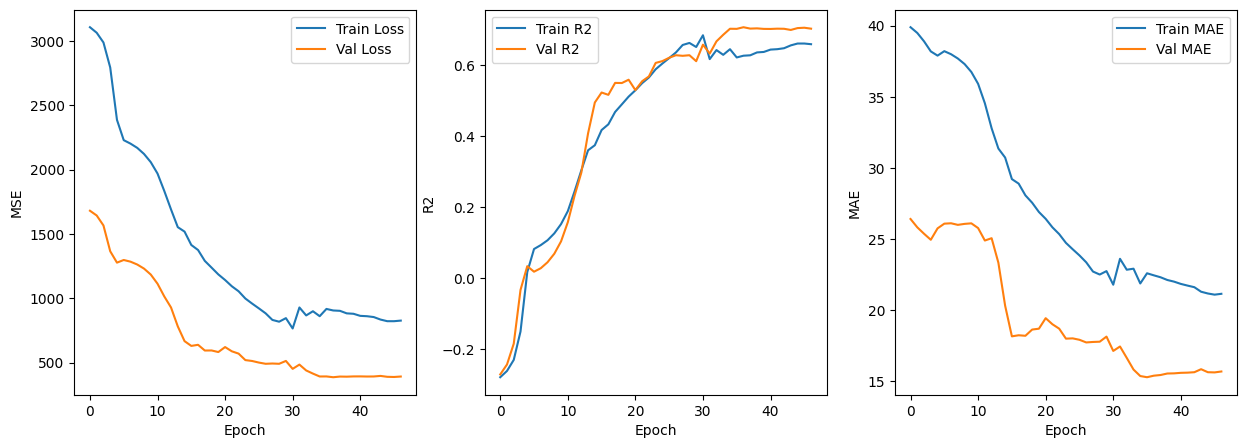

In [32]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='val_R2', min_delta = 0.001, mode= 'max', 
                                         patience=10, restore_best_weights=True)

model_reg4.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20, callbacks=[callback])

# Plot the training history
history = model_reg4.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


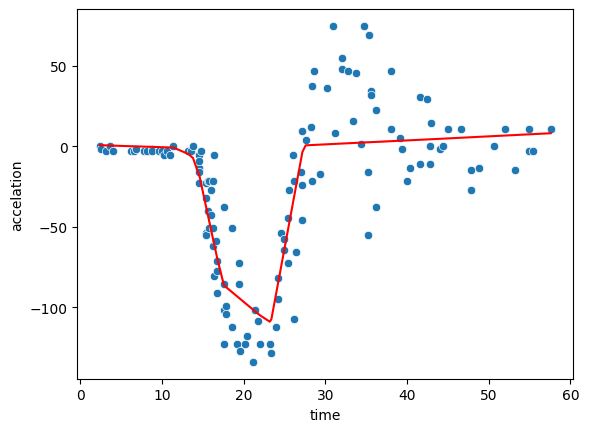

In [33]:
# Compute predictions
yhat = model_reg4.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat.reshape(-1), c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

Here, I decided to increase the patience, but at the same time allowed a larger minimum delta to compensate. Since R2 is recorded in the scale [0,1], it is easier to determine a reasonable value of minimum delta. Hence the choice to monitor R2.

As can be expected, increasing the patience, increases the number of epochs. 

### 🚩 Exercise 6 (EXTRA)

For comparison, let's fit kernel ridge regression model with radial basis function. 

- Try changing the value of gamma in the code below. How does it effect the regression function?
- Try changing the value of alpha in the code below. How does it effect the regression function?
- Comment on which model you prefer (neural network or kernel ridge) both in terms of predictive performance and ease of implementation.

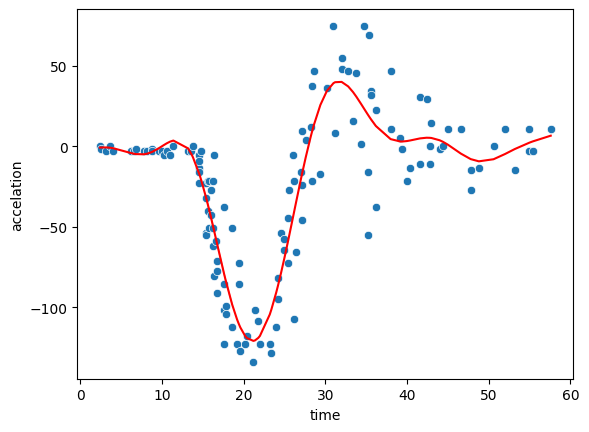

In [34]:
from sklearn.kernel_ridge import KernelRidge

# Define and fit the model
kr = KernelRidge(alpha = 0.1, kernel='rbf', gamma=4).fit(X,y)

# Compute predictions
yhat = kr.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat, c = 'red')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

Changing the value of:
- `gamma`: decreasing gamma makes the function flatter, with more smoothing of the effects over time; instead increasing gamma makes the function more wiggly.
- `alpha`: increasing alpha smoothes the effects over time, while decreasing alpha has the opposite effect

The fit seems slightly better with kernel ridge compared to the neural network. In addition, kernel ridge is much easier and faster to implement, with much fewer parameters to tune. 

### Heteroskedastic regression with a custom loss

Our previous model only provided an estimate of the mean function for acceleration as a function of time. However, visually, it is evident that the variance of acceleration also varies with time. 

Let's define a custom loss function for the case of heteroskedastic regression. In this case, the loss corresponds to the negative log likelihood of the Gaussian with unknown mean and standard deviation (see Lecture 9 Notes). Here, our neural network model will output both the mean and standard deviation, we have concantenated them together to output an matrix with two columns (the first for the mean, and the second for the standard deviation).

In [35]:
# Gaussian NLL as a custom loss 
def my_loss(y_true, y_pred):   
    mu_pred = y_pred[:, 0]
    sigma_pred = y_pred[:, 1]  
    y_true = tf.cast(y_true, mu_pred.dtype)    
    y_true = tf.reshape(y_true, tf.shape(mu_pred))   

    # NLL (up to a constant): 0.5 * ((y - mu)/sigma)^2 + log(sigma)    
    sq_term = 0.5 * tf.square((y_true - mu_pred) / sigma_pred)    
    log_term = tf.math.log(sigma_pred)    
    nll = sq_term + log_term    
    
    # Reduce mean over batch    
    return tf.reduce_mean(nll)

Now, let's start with a simple model for illustration. We will keep the same architecture for the mean, but for the standard deviation, for simplicity, we assume no hidden layer (it depends only on the inputs directly, i.e. subject to the nonlinear activation, there is a linear relation between time and the standard deviation of acceleration).

For the ouput of the standard deviaton, we use the `softplus` activation to ensure that it is positive. 

In [38]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_mean = keras.layers.Dense(1, activation='linear') (hidden_layer2)
output_sigma = keras.layers.Dense(1, activation='softplus') (input_layer)
stack = keras.layers.Concatenate()([output_mean, output_sigma])
model_reg_het = keras.Model(input_layer, stack)

model_reg_het.compile(
    loss=my_loss,
    optimizer= keras.optimizers.SGD(learning_rate=0.001),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

### 🚩 Exercise 7 (CORE)

Train the model for as many epochs as needed (when early stopping exits), and plot the mean function, also with lines for +/- 2*standard deviation, overlaid on top of a scatterplot of the data.

How does the model perform?

_Note: if it exits without training, re-initialize by running the code cell above again._

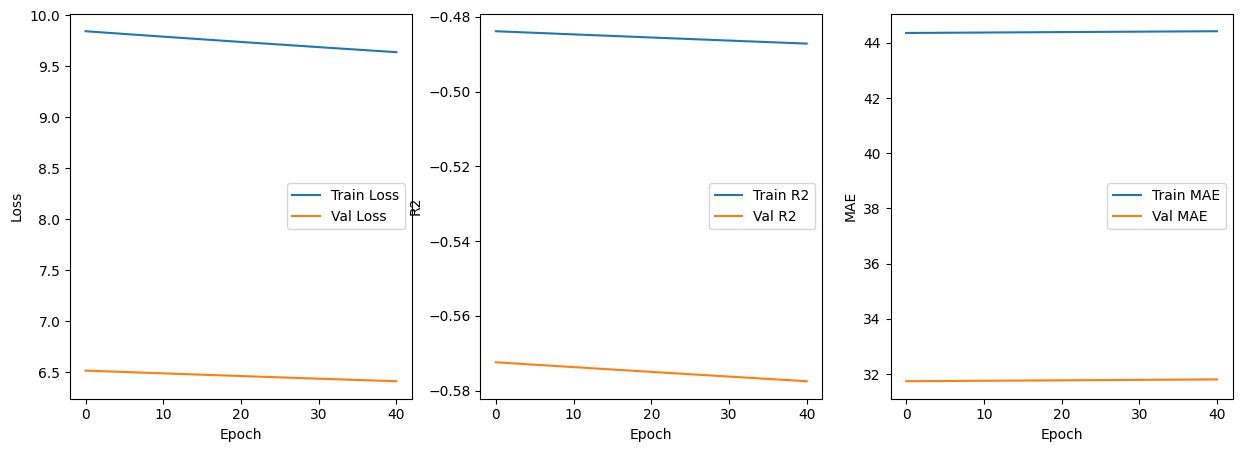

In [41]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='loss', min_delta = 0.05, mode ='min', 
                                         patience=10, restore_best_weights=True)

model_reg_het.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20, callbacks=[callback])

# Plot the training history
history = model_reg_het.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


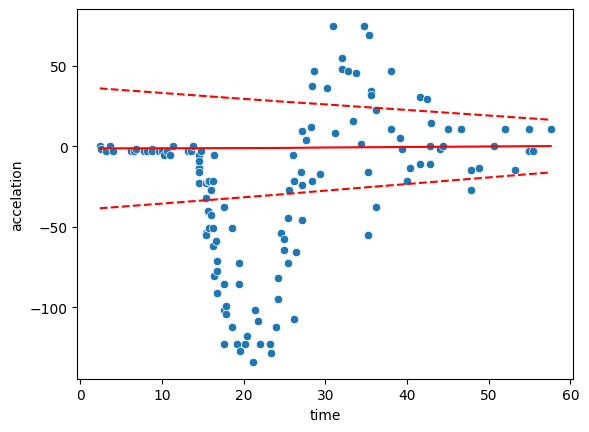

In [42]:
# Compute predictions
yhat = model_reg_het.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat[:,0], c = 'red')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat[:,0]+2*yhat[:,1], c = 'red', linestyle='dashed')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat[:,0]-2*yhat[:,1], c = 'red', linestyle='dashed')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

Although the training and validation loss are still slightly decreasing, we have trained for a number of epochs and the improvement with more epochs is minimal (indeed the early stopping criteria is reached after running the fit code cell a few times).

The performance of the model is quite poor. It gets stuck in a local mode which explains all variation in the data as noise.

### Regularization

The heteroskedastic model performs quite poor, explaining most of the variation in the data as noise. Since the noise term is too large, we can try to include regularization to shrink the weights and bias of the layer that models the standard deviation. In this case, we want to shrink the weights AND bias, as the bias controls the overall level of variance, which is estimated to be large in our previous model.

In this, case when defining our activation function `keras.layers.Dense`, we will use the options:
- `bias_regularizer`
- `kernel_regularizer`

Available regularizers are provided in: https://keras.io/api/layers/regularizers/

### 🚩 Exercise 8 (CORE)

Modify your previous model to include $L_2$ regularization for `output_sigma` layer. Use a penalty parameter of 1.0 for the bias and 0.01 for the weights.

Train the model for as many epochs as needed (when early stopping exits), and plot the mean function, also with lines for +/- 2*standard deviation, overlaid on top of a scatterplot of the data.

How does the model perform?

_Note: if trained long enough, you should reach an R2 around 0.2 on the training data. If it stops before then, it has been initialized poorly and you should rerun the initial model definition to reinitialize with the weights and biases._

In [45]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
hidden_layer1 = keras.layers.Dense(20, activation='relu') (input_layer)
hidden_layer2 = keras.layers.Dense(10, activation='relu') (hidden_layer1)
output_mean = keras.layers.Dense(1, activation='linear') (hidden_layer2)
output_sigma = keras.layers.Dense(1, activation='softplus',bias_regularizer=keras.regularizers.L2(1.0),
                                  kernel_regularizer=keras.regularizers.L2(0.01)) (input_layer)
stack = keras.layers.Concatenate()([output_mean, output_sigma])
model_reg_het = keras.Model(input_layer, stack)

model_reg_het.compile(
    loss=my_loss,
    optimizer= keras.optimizers.SGD(learning_rate=0.001),
    metrics=[
       keras.metrics.R2Score(name='R2'),
       keras.metrics.MeanAbsoluteError(name='MAE')
    ],
)

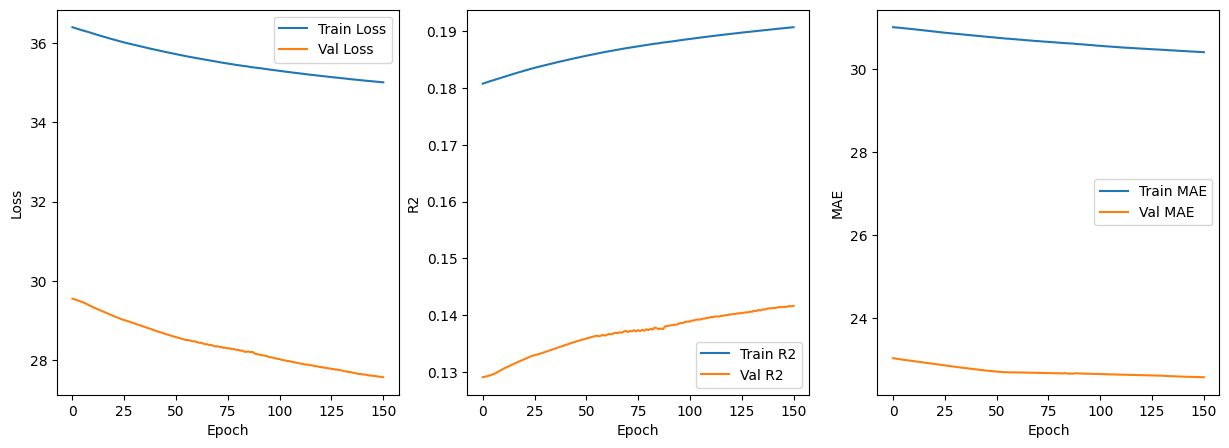

In [51]:
# Fit the model
callback = keras.callbacks.EarlyStopping(monitor='loss', min_delta = 0.05, mode = 'min', 
                                         patience=10, restore_best_weights=True)

model_reg_het.fit(x=X, y=y, epochs=300, shuffle=True, validation_split=0.1, verbose=0, batch_size=20, callbacks=[callback])

# Plot the training history
history = model_reg_het.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['R2'], label='Train R2')
ax[1].plot(history['val_R2'], label='Val R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
ax[1].legend()
ax[2].plot(history['MAE'], label='Train MAE')
ax[2].plot(history['val_MAE'], label='Val MAE')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('MAE')
ax[2].legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


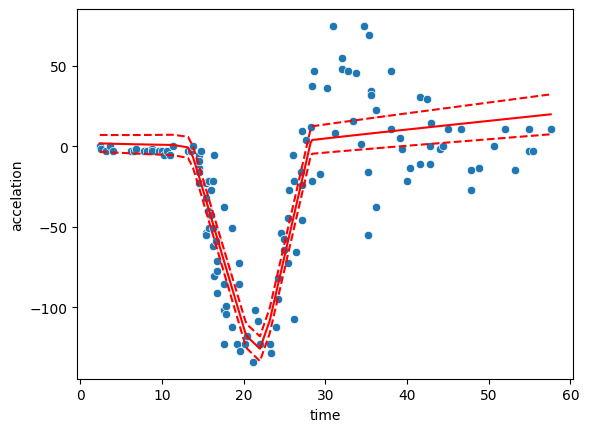

In [52]:
# Compute predictions
yhat = model_reg_het.predict(X)

# Add them to the plot
sns.scatterplot(mcycle, x = 'times', y = 'accel')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat[:,0], c = 'red')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat[:,0]+2*yhat[:,1], c = 'red', linestyle='dashed')
sns.lineplot(x = ss.inverse_transform(X).reshape(-1), y = yhat[:,0]-2*yhat[:,1], c = 'red', linestyle='dashed')
plt.xlabel('time')
plt.ylabel('accelation')
plt.show()

The model performs much better now. It captures changes in the mean of acceleration as time varies, as well as some increases in the standard deviation as times increases.

When can of course tune and tweak the model further to try to get better performance. This can take some time. Instead, we will look at another dataset to understand how to wrap our keras model into sklearn's pipeline.

# Part 2: Hitters Data

In the second part of this workshop, we will work with the hitters data, which was used in the Introduction to Statistical Learning (2023). The data records a number of statistics and salaries for baseball players. We wish to predict a baseball player's salary on the basis of various statistics
associated with performance in the previous year.

In this part of the workshop, we will understand how to wrap our keras model into sklearn's pipeline to include our feature engineering steps.

Let's start by loading the data and looking at some basic information to understand what feature engineering steps are needed.

In [53]:
hitters = pd.read_csv('Hitters.csv')

In [54]:
hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [55]:
hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

There are 20 variables in total, with 3 of them being of type object. We will need to do some encoding of these features. 

We see that there are some missing values in salaries of players. Since this is our target variables, we will drop these missing values. Although it would be interesting to check if those who are missing salaries have different characteristics in terms of their features (_not pursued here_); this might signal an informative missing mechanism and that our predictive model may only be applicable to a subpopulation of baseball players. 

In [56]:
# Remove observations with missing target variable
hitters = hitters.dropna()
N = hitters.shape[0]
D = hitters.shape[1]-1
print('Number of observations:', N)
print('Number of features:', D)

Number of observations: 263
Number of features: 19


For the pairplot below, we observe high correlation among some of the features.  Also since the numeric variables are on very different scales, we need to do some feature scaling. 

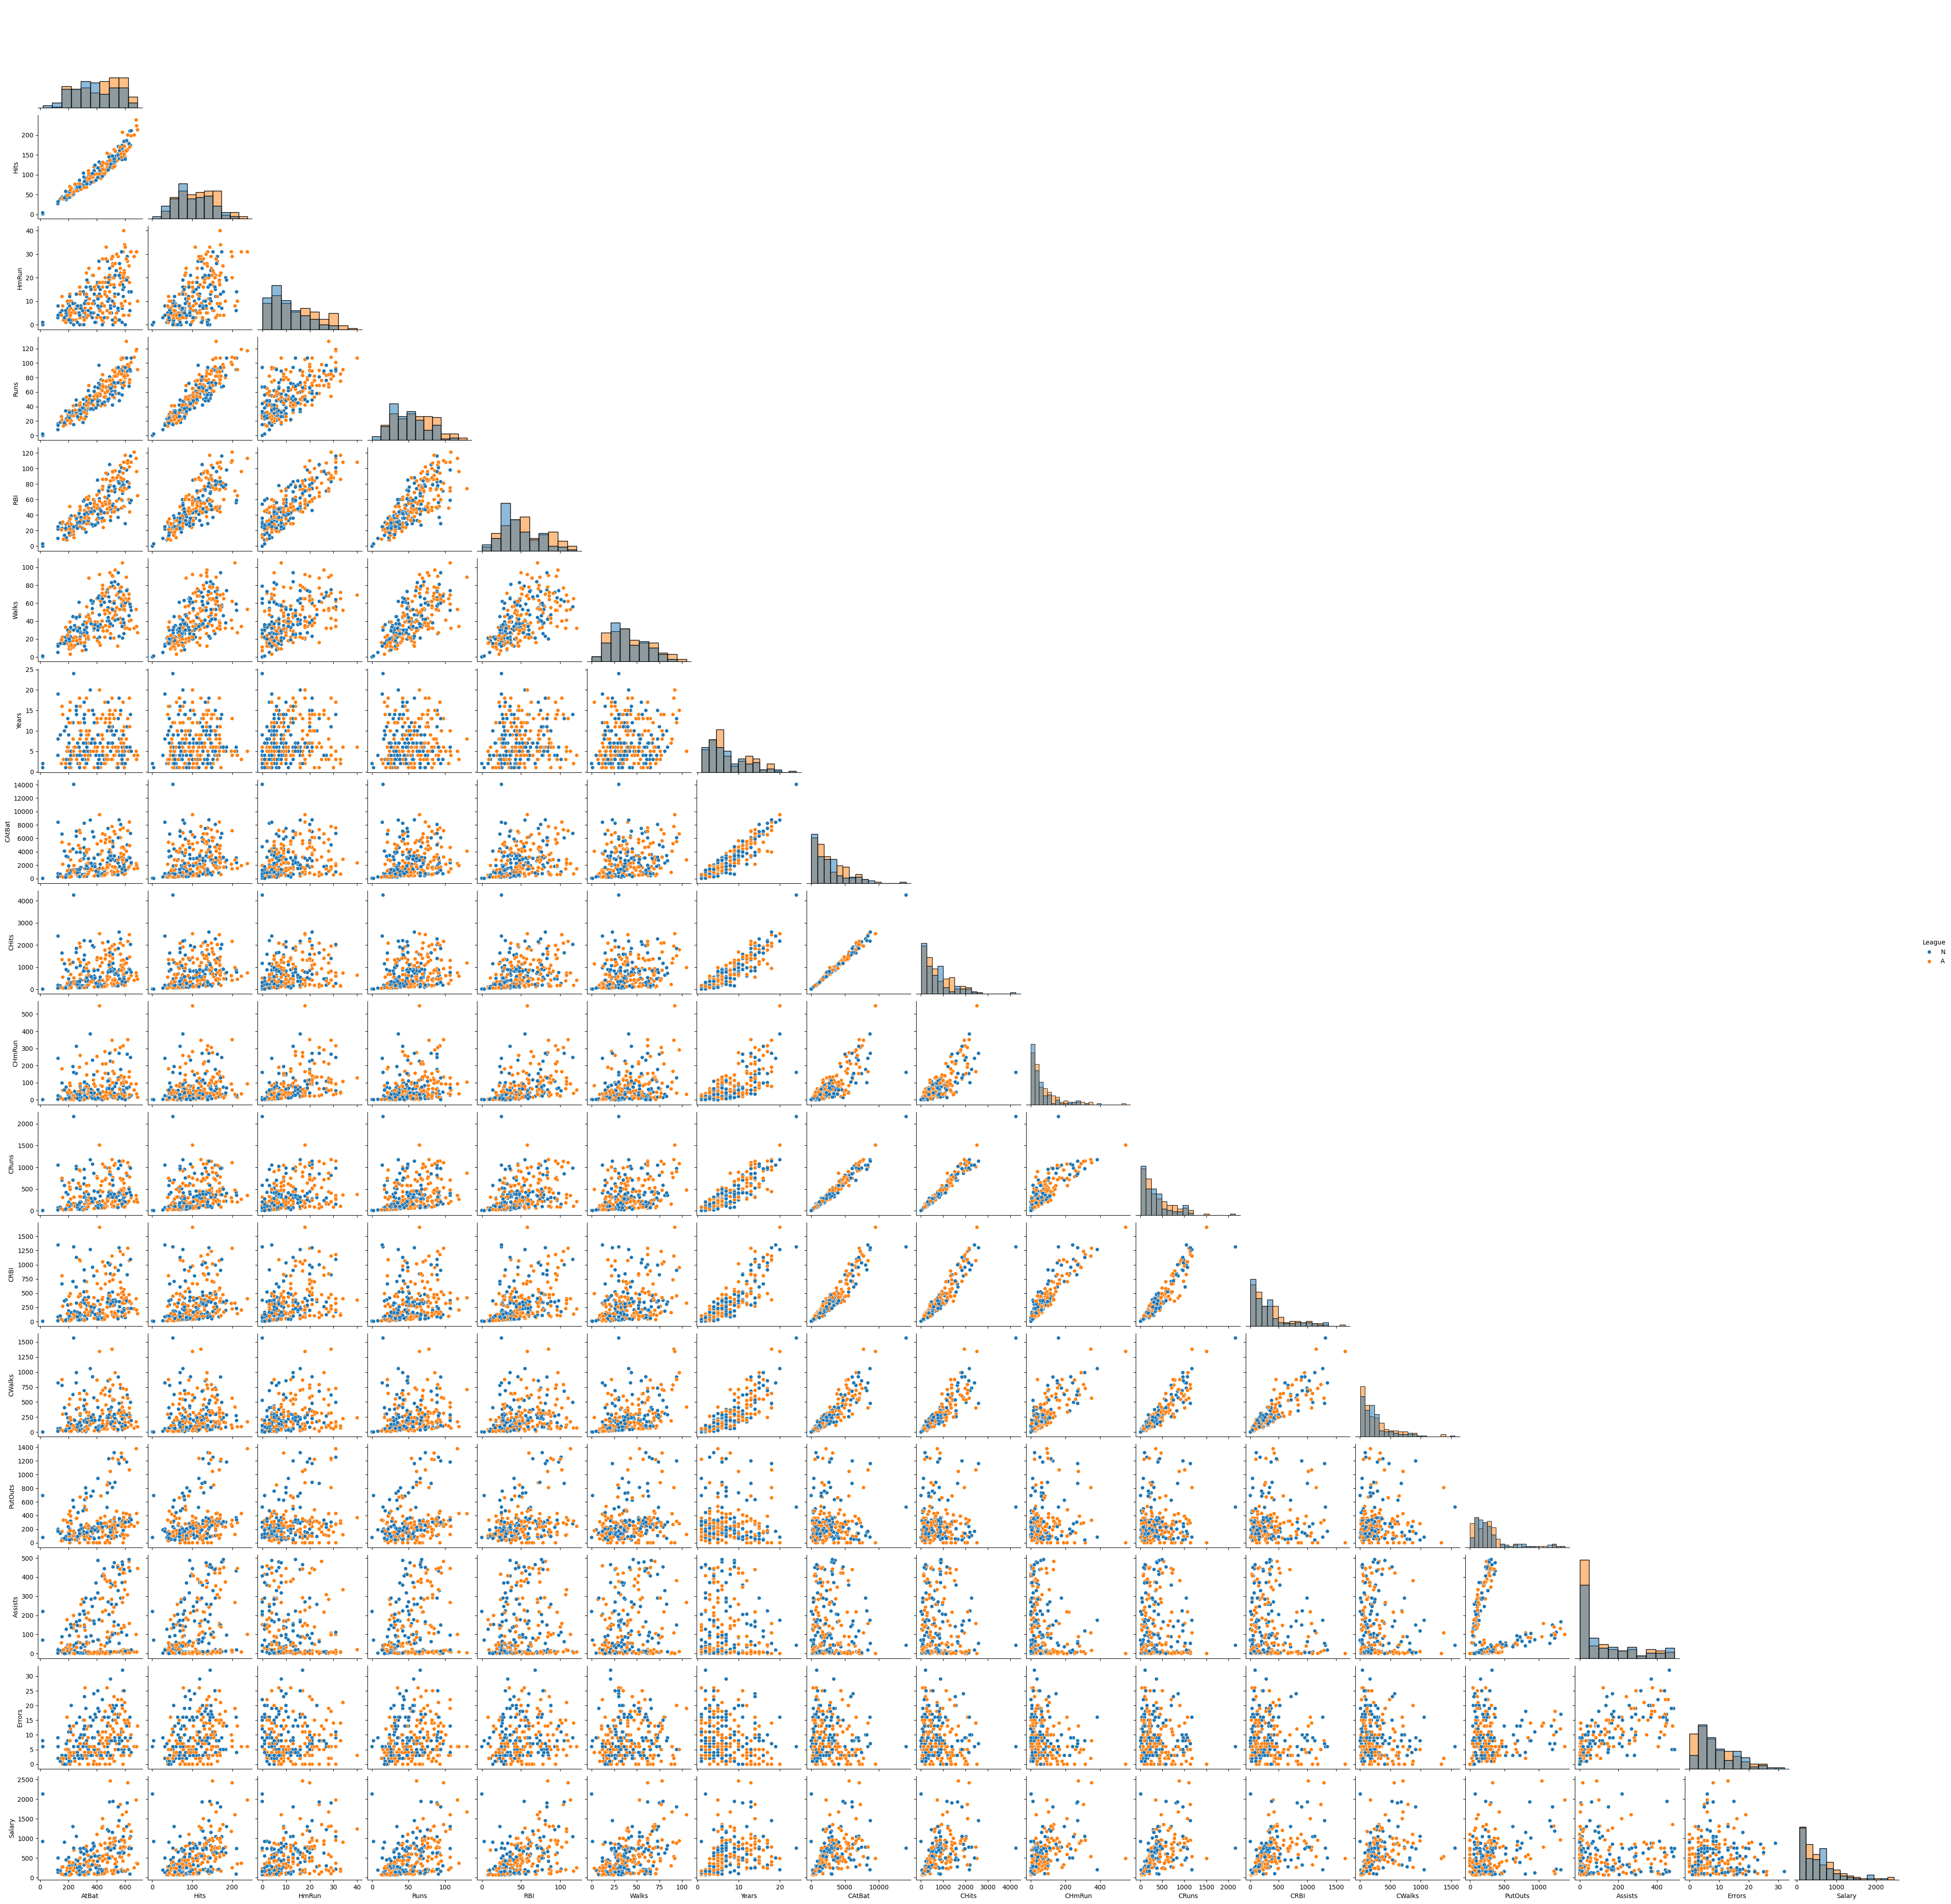

In [57]:
sns.pairplot(hitters, corner=True, diag_kind='hist', hue = 'League')
plt.show()

Checking the distribution of the categorical features, we see that they are all binary variables and there are no rare categories.

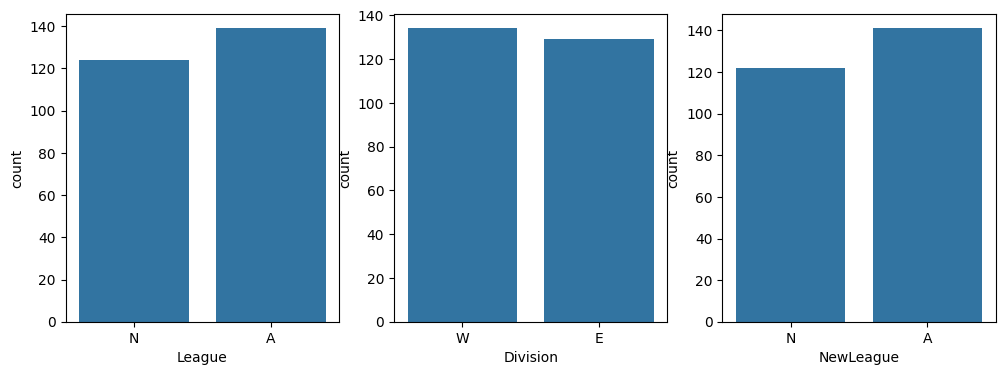

In [58]:
fig, ax = plt.subplots(1,3, figsize = (12,4))
sns.countplot(hitters, x='League', ax =ax[0])
sns.countplot(hitters, x='Division', ax =ax[1])
sns.countplot(hitters, x='NewLeague', ax =ax[2])
plt.show()

Before we define our model, let's start by splitting into a training and test set.

In [59]:
from sklearn.model_selection import train_test_split
y = hitters['Salary']
X = hitters.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

We are now ready to define our feature engineering steps to be used in our model pipeline. We will use standard scaling for the numerical variables and one hot encoding for the binary features.

In [60]:
# Feature engineering steps
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Names of numeric features
num_features = X_train.columns[X_train.dtypes=='int64']
# Names of categorical features
cat_features = X_train.columns[X_train.dtypes=='object']

preprocessor = make_column_transformer(
    (StandardScaler(), num_features),
    (OneHotEncoder(drop='first'),cat_features),
    verbose_feature_names_out=False
)

### Baseline linear regression

We start by fitting a baseline linear regression model and investigating performance on the test data.

In [61]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

lm = make_pipeline(
    preprocessor,
    LinearRegression()
).fit(X_train, y_train)

In [62]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

yhat_test = lm.predict(X_test)
print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

R2: 0.32755419829816956
RMSE: 361.49290233703255
MAE: 262.1650106760911


The R2 is relatively low, but an advantage of the linear regression model is that we can examine the coefficients to understand the effect of the different features.

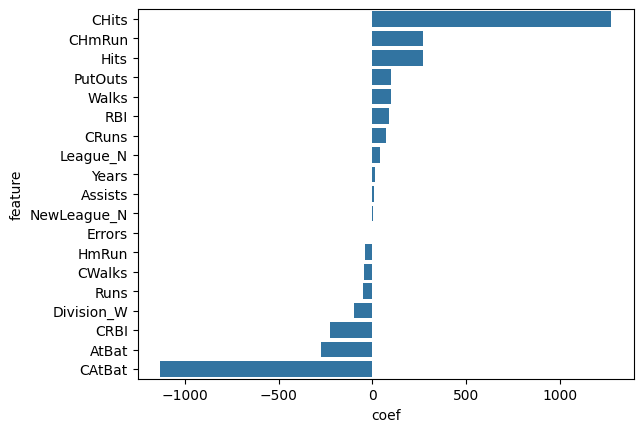

In [63]:
coefs = pd.DataFrame({'feature': lm[:-1].get_feature_names_out(), 
                      'coef': lm[-1].coef_}).sort_values ("coef", ascending=False)
coefs
sns.barplot(coefs, y= 'feature', x = 'coef')
plt.show()

### Wrapping keras model into an sklearn regression model

Our first step to turn our keras model into an sklearn regressor is to define the neural network model. We define a general MLP that can be constructed by passing in the desired number of neurons in each layer.

In [64]:
def mlp_model(X, y, lr = 0.001, layers=[64]):
    # Creates a basic MLP model 
    D = X.shape[1]
    input_layer = keras.layers.Input(shape=(D,))

    hidden_layer = input_layer
    for layer_width in layers:
        hidden_layer = keras.layers.Dense(layer_width, activation="relu")(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer)

    model = keras.Model(input_layer, output_layer)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr),
                  metrics=[keras.metrics.R2Score(name='R2')])

    return model

Next, we simply use keras's sklearn wrappers: https://keras.io/api/utils/sklearn_wrappers/ 

This allows us to turn our keras model into an sklearn model. Through `model_kwargs`, we can specify the arguments of our `mlp_model` and through `fit_kwargs`, we can specify the arguments that we usually pass into keras's `.fit()`.

In [65]:
from keras.wrappers import SKLearnRegressor

nn = SKLearnRegressor(
    model=mlp_model,
    model_kwargs={
        "layers": [64],
    },
    fit_kwargs={
        "epochs": 1000, 
        "shuffle": True, 
        "verbose": 0, 
        "batch_size": 20, 
        "callbacks": [keras.callbacks.EarlyStopping(monitor='R2', min_delta = 0.001, mode = 'max', 
                                                    patience=5, restore_best_weights=True)]
    }
)

Now, that is a sklearn model, we can simply use pipelines to combine the preprocessing steps with our estimator!

In [66]:
nn_pip = make_pipeline(
    preprocessor,
    nn
).fit(X_train, y_train)

Let's plot the history to check that we have trained the model for long enough.

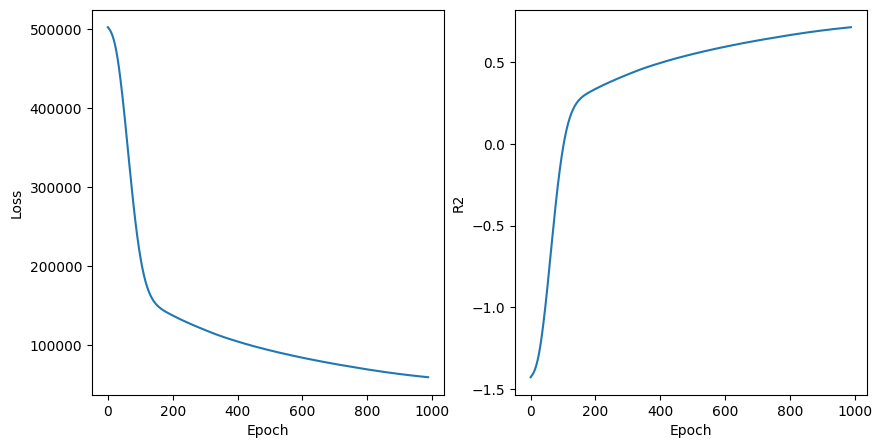

In [67]:
# Plot the training history
history =nn_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(history['R2'], label='Train R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
plt.show()

Finally, let's check the performance of our model.

In [68]:
yhat_test = nn_pip.predict(X_test)

print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R2: 0.6056157188441198
RMSE: 276.8413318679011
MAE: 189.42872138152723


The performance is better than the linear model!

### 🚩 Exercise 9 (CORE)

Try training a deeper model, with your choice of depth and width.

How does the model perform?

In [69]:
nn = SKLearnRegressor(
    model=mlp_model,
    model_kwargs={
        "layers": [32, 32, 16, 8],
    },
    fit_kwargs={
        "epochs": 1000, 
        "shuffle": True, 
        "verbose": 0, 
        "batch_size": 20, 
        "callbacks": [keras.callbacks.EarlyStopping(monitor='R2', min_delta = 0.001, mode = 'max', 
                                                    patience=5, restore_best_weights=True)]
    }
)

In [70]:
nn_pip = make_pipeline(
    preprocessor,
    nn
).fit(X_train, y_train)

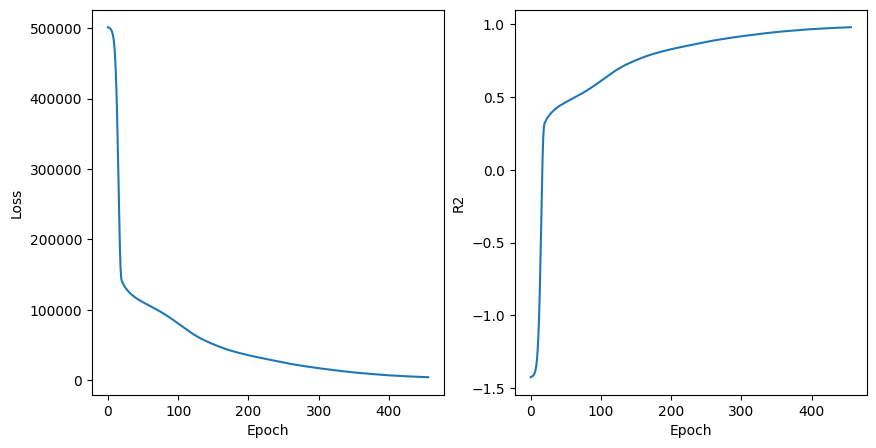

In [71]:
# Plot the training history
history =nn_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(history['R2'], label='Train R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
plt.show()

In [72]:
yhat_test = nn_pip.predict(X_test)

print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
R2: 0.5649681428405261
RMSE: 290.75799274927306
MAE: 197.55889760841174


We choose a deeper model with four layers of sizes, 32, 32, 16, 8. The performance of the model is worse than the shallow model.

### 🚩 Exercise 10 (CORE)

Define a new MLP model, by altering the previous model to include $L_1$ regularization. You should define your model so that you can pass in different penalty parameters for each layer. 

Now train you deeper model from Exercise 9, but with $L_1$ regularization for your choice of penalty parameters.

How does the model perform?

In [73]:
def mlp_model_l1(X, y, lr = 0.001, layers=[64], lmbds = [0.01]):
    # Creates a basic MLP model with l1 regularization
    D = X.shape[1]
    input_layer = keras.layers.Input(shape=(D,))

    hidden_layer = input_layer
    for i, layer_width in enumerate(layers):
        hidden_layer = keras.layers.Dense(layer_width, activation="relu",
                                          kernel_regularizer=keras.regularizers.L1(lmbds[i]))(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer)

    model = keras.Model(input_layer, output_layer)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr),
                  metrics=[keras.metrics.R2Score(name='R2')])

    return model

In [82]:
nn = SKLearnRegressor(
    model=mlp_model_l1,
    model_kwargs={
        "layers": [32, 32, 16, 8],
        "lmbds": [0.01, 0.01, 0.001, 0.001]
    },
    fit_kwargs={
        "epochs": 1000, 
        "shuffle": True, 
        "verbose": 0, 
        "batch_size": 20, 
        "callbacks": [keras.callbacks.EarlyStopping(monitor='R2', min_delta = 0.001, mode = 'max',
                                                    patience=5, restore_best_weights=True)]
    }
)

In [83]:
nn_pip = make_pipeline(
    preprocessor,
    nn
).fit(X_train, y_train)

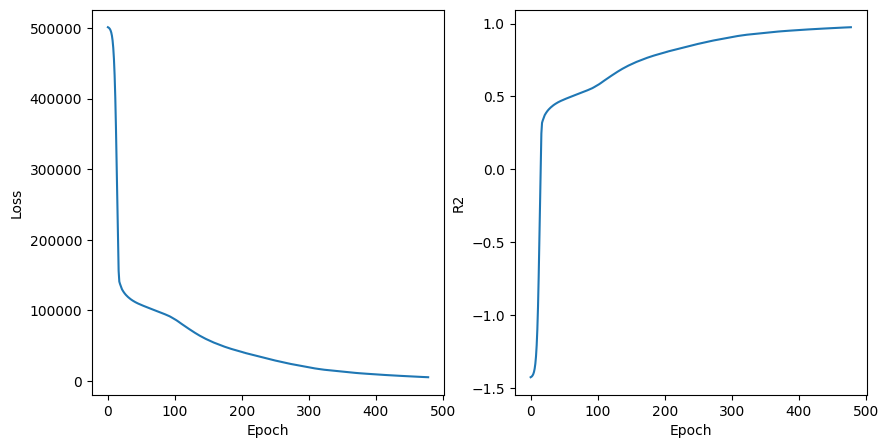

In [84]:
# Plot the training history
history =nn_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(history['R2'], label='Train R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
plt.show()

In [85]:
yhat_test = nn_pip.predict(X_test)

print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
R2: 0.5875697340155746
RMSE: 283.10425418883347
MAE: 192.91440127107464


The deeper model's performance is better with l1 regularization, but worse than the shallow model. Note here if you rerun, with different intializations, you can appreciate how the model converges to different local modes. Sometimes, it does worse than the deep model, and sometimes better than the shallow model.

### 🚩 Exercise 11 (EXTRA)

Define a new MLP model, but instead of using $L_1$ regularization, use dropout to help avoid overfitting. After defining each hidden layer, you need to add another line in your model, including a `keras.layers.Dropout` layer, see https://keras.io/api/layers/regularization_layers/dropout/

You should define your model so that you can pass in different dropout rates for each layer. 

Now train you deeper model from Exercise 9, but with dropout for your choice of rates.

How does the model perform?

In [86]:
def mlp_model_dropout(X, y, lr = 0.001, layers=[64], rates = [0.1]):
    # Creates a basic MLP model with dropout
    D = X.shape[1]
    input_layer = keras.layers.Input(shape=(D,))

    hidden_layer = input_layer
    for i, layer_width in enumerate(layers):
        hidden_layer = keras.layers.Dense(layer_width, activation="relu")(hidden_layer)
        hidden_layer = keras.layers.Dropout(rates[i])(hidden_layer)

    output_layer = keras.layers.Dense(1, activation='linear') (hidden_layer)

    model = keras.Model(input_layer, output_layer)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr),
                  metrics=[keras.metrics.R2Score(name='R2')])

    return model

In [87]:
nn = SKLearnRegressor(
    model=mlp_model_dropout,
    model_kwargs={
        "layers": [32, 32, 16, 8],
        "rates": [0.001,0.001,0.0001,0.0001]
    },
    fit_kwargs={
        "epochs": 1000, 
        "shuffle": True, 
        "verbose": 0, 
        "batch_size": 20, 
        "callbacks": [keras.callbacks.EarlyStopping(monitor='R2', min_delta = 0.001, mode = 'max',
                                                    patience=5, restore_best_weights=True)]
    }
)

In [88]:
nn_pip = make_pipeline(
    preprocessor,
    nn
).fit(X_train, y_train)

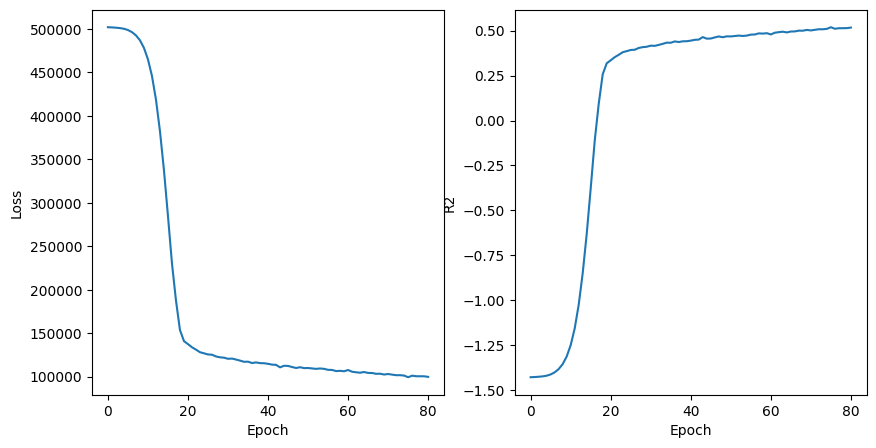

In [89]:
# Plot the training history
history =nn_pip[-1].model_.history.history
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[1].plot(history['R2'], label='Train R2')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('R2')
plt.show()

In [90]:
yhat_test = nn_pip.predict(X_test)

print('R2:', r2_score(y_test, yhat_test))
print('RMSE:', root_mean_squared_error(y_test, yhat_test))
print('MAE:', mean_absolute_error(y_test, yhat_test))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
R2: 0.41268036921162277
RMSE: 337.8379164135547
MAE: 260.4298797340831


The dropout model performs worse in the case, but changing the parameters (e.g. rates, learning rates, or batch size) could improve the model. 

# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
#!jupyter nbconvert --to pdf mlp_week10_key.ipynb 